In [75]:
import pandas as pd
import numpy as np
import seaborn as sns


In [57]:
data = {
    'StudentID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva', 'Frank', 'Grace', 'Henry', 'Ivy', 'Jack'],
    'Math_Score': [88, 92, np.nan, 95, 45, 85, 99, 70, 65, 105],
    'Science_Score': [78, 85, 80, 82, np.nan, 89, 94, 68, 73, 150],
    'Attendance_Percentage': [92, 88, 95, 60, 85, np.nan, 100, 75, 65, 90]
}
df = pd.DataFrame(data)

In [58]:
df.isnull().sum()

StudentID                0
Name                     0
Math_Score               1
Science_Score            1
Attendance_Percentage    1
dtype: int64

In [60]:
df['Math_Score'].fillna(df['Math_Score'].mean(), inplace=True)
df['Science_Score'].fillna(df['Science_Score'].mean(), inplace=True)
df['Attendance_Percentage'].fillna(df['Attendance_Percentage'].mean(), inplace=True)
df.isnull().sum()

/tmp/ipykernel_22296/3958875205.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Math_Score'].fillna(df['Math_Score'].mean(), inplace=True)
/tmp/ipykernel_22296/3958875205.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

StudentID                0
Name                     0
Math_Score               0
Science_Score            0
Attendance_Percentage    0
dtype: int64

In [61]:
def remove_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3-Q1

    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] > high, high, np.where(df[column] < low, low, df[column]))


<Axes: >

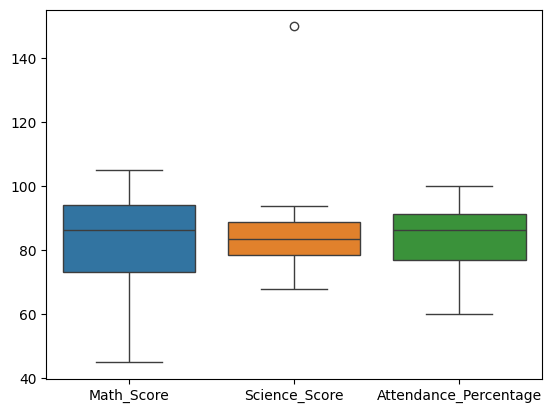

In [62]:
sns.boxplot(data=df[["Math_Score","Science_Score","Attendance_Percentage"]])

In [66]:
remove_outliers("Science_Score")
remove_outliers("Math_Score")


<Axes: >

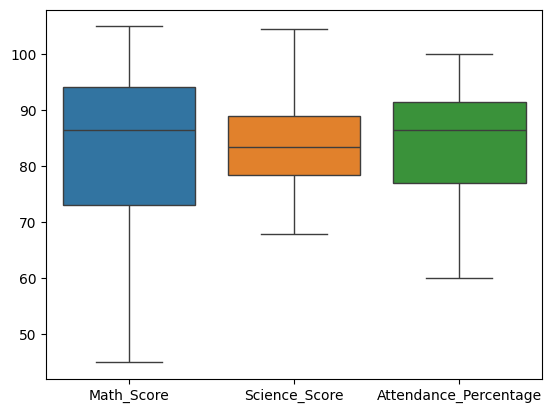

In [67]:
sns.boxplot(data=df[["Math_Score","Science_Score","Attendance_Percentage"]])

In [68]:
# Skewness:
from scipy.stats import skew

print("Skewness before log Transformation on Science_score: ", skew(df["Science_Score"]))
df['Science_Score_Log'] = np.log(df["Science_Score"] + 1)
print("Skewness after log Transformation on Science_score: ", skew(df["Science_Score_Log"]))


Skewness before log Transformation on Science_score:  0.3522729456870717
Skewness after log Transformation on Science_score:  0.08591114056416885


In [71]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Min-Max Scaling
scaler_minMax = MinMaxScaler()
df['Math_Score_MinMax'] = scaler_minMax.fit_transform(df[['Math_Score']])

scaler_zscore = StandardScaler()
df['Math_Score_Zscore'] = scaler_zscore.fit_transform(df[['Math_Score']])

print("\nTransformed Dataset:\n", df[['Math_Score', 'Math_Score_MinMax', 'Math_Score_Zscore']])



Transformed Dataset:
    Math_Score  Math_Score_MinMax  Math_Score_Zscore
0   88.000000           0.716667           0.311577
1   92.000000           0.783333           0.545259
2   82.666667           0.627778           0.000000
3   95.000000           0.833333           0.720521
4   45.000000           0.000000          -2.200510
5   85.000000           0.666667           0.136315
6   99.000000           0.900000           0.954204
7   70.000000           0.416667          -0.739995
8   65.000000           0.333333          -1.032098
9  105.000000           1.000000           1.304727


Text(0.5, 1.0, 'Original Math Score')

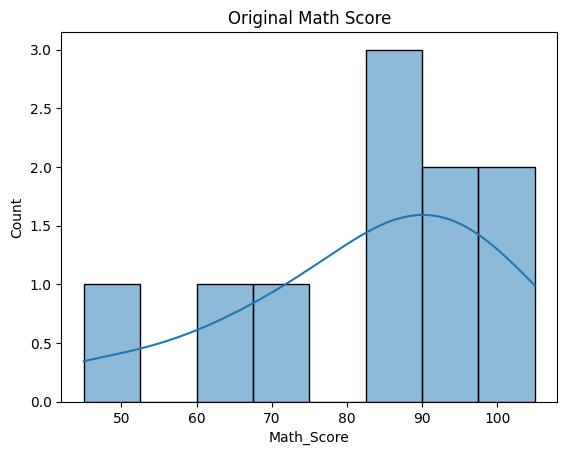

In [72]:
sns.histplot(df['Math_Score'], bins=8, kde=True)
plt.title("Original Math Score")

Text(0.5, 1.0, 'Min-Max Scaled')

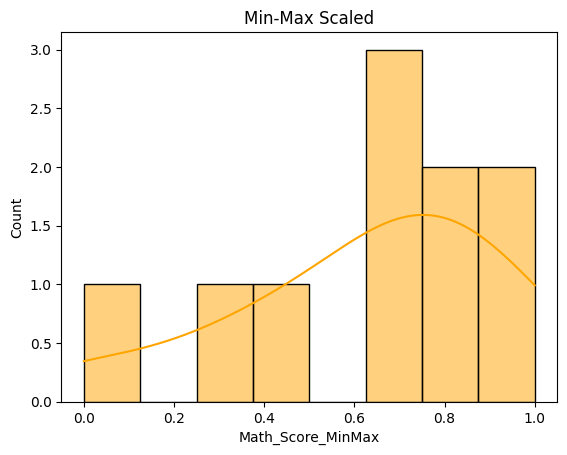

In [73]:
sns.histplot(df['Math_Score_MinMax'], bins=8, kde=True, color='orange')
plt.title("Min-Max Scaled")

Text(0.5, 1.0, 'Z-score Standardized')

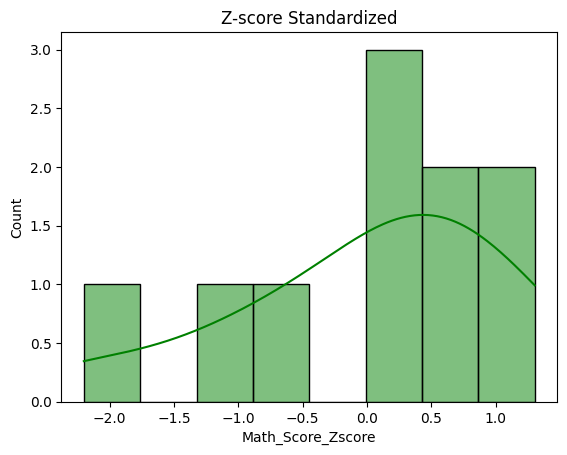

In [74]:
sns.histplot(df['Math_Score_Zscore'], bins=8, kde=True, color='green')
plt.title("Z-score Standardized")